# Singapore Job Postings Salary Benchmarking Project

## Objective
Analyze salary data, clean outliers, and understand salary distribution trends in Singapore job postings.

## Task 1: Salary Data Cleaning & Outlier Handling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("SGJobData.csv")
df.head()

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0


In [16]:
df.columns

Index(['categories', 'employmentTypes', 'metadata_expiryDate',
       'metadata_isPostedOnBehalf', 'metadata_jobPostId',
       'metadata_newPostingDate', 'metadata_originalPostingDate',
       'metadata_repostCount', 'metadata_totalNumberJobApplication',
       'metadata_totalNumberOfView', 'minimumYearsExperience',
       'numberOfVacancies', 'occupationId', 'positionLevels',
       'postedCompany_name', 'salary_maximum', 'salary_minimum', 'salary_type',
       'status_id', 'status_jobStatus', 'title', 'average_salary'],
      dtype='object')

In [26]:
df["salary"].isnull().sum()

0

## Missing Value Check

No missing values were found in the salary column. Therefore, no imputation or data filling was required.

In [19]:
df["salary"] = (df["salary_minimum"] + df["salary_maximum"]) / 2

In [20]:
df["salary"].describe()

count    1.048585e+06
mean     4.769445e+03
std      2.547809e+04
min      0.000000e+00
25%      2.900000e+03
50%      3.800000e+03
75%      5.500000e+03
max      1.266640e+07
Name: salary, dtype: float64

In [21]:
print("Before max:", df["salary"].max())

Before max: 12666400.0


In [22]:
lower = df["salary"].quantile(0.01)
upper = df["salary"].quantile(0.99)

df_clean = df[(df["salary"] >= lower) & (df["salary"] <= upper)]

In [23]:
print("After max:", df_clean["salary"].max())

After max: 16666.5


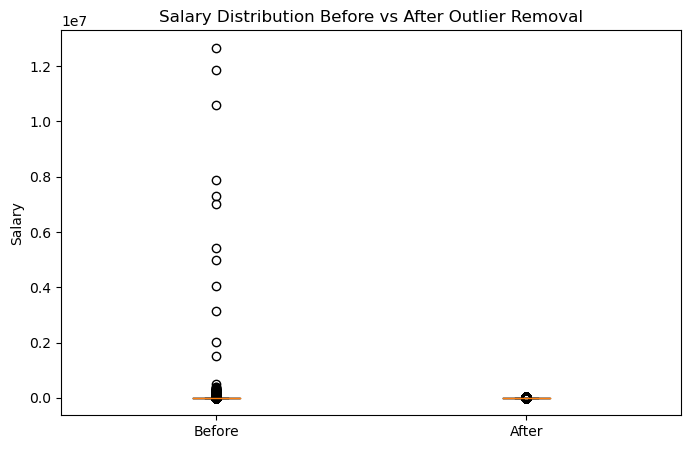

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot([df["salary"], df_clean["salary"]], labels=["Before", "After"])

plt.title("Salary Distribution Before vs After Outlier Removal")
plt.ylabel("Salary")
plt.show()